Saving archive (3).zip to archive (3).zip
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


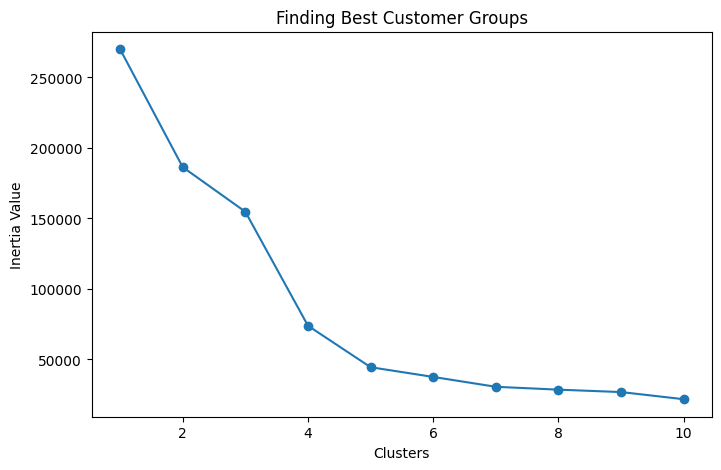

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  Group
0           1    Male   19                  15                      39      4
1           2    Male   21                  15                      81      2
2           3  Female   20                  16                       6      4
3           4  Female   23                  16                      77      2
4           5  Female   31                  17                      40      4


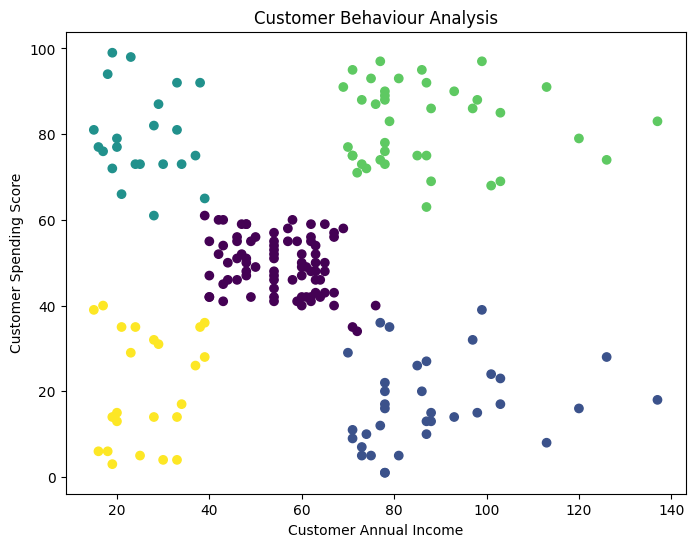

Group
0    81
3    39
1    35
4    23
2    22
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from google.colab import files
uploaded = files.upload()

customer_data = pd.read_csv(next(iter(uploaded)))

print(customer_data.head())

selected_data = customer_data[['Annual Income (k$)', 'Spending Score (1-100)']]

cluster_values = []

for num in range(1, 11):
    model = KMeans(n_clusters=num, random_state=1)
    model.fit(selected_data)
    cluster_values.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), cluster_values, marker='o')

plt.title("Finding Best Customer Groups")
plt.xlabel("Clusters")
plt.ylabel("Inertia Value")

plt.show()

model = KMeans(n_clusters=5, random_state=1)

customer_groups = model.fit_predict(selected_data)

customer_data['Group'] = customer_groups

print(customer_data.head())

plt.figure(figsize=(8,6))

plt.scatter(
    customer_data['Annual Income (k$)'],
    customer_data['Spending Score (1-100)'],
    c=customer_data['Group']
)

plt.xlabel("Customer Annual Income")
plt.ylabel("Customer Spending Score")

plt.title("Customer Behaviour Analysis")

plt.show()

group_count = customer_data['Group'].value_counts()

print(group_count)